## Multi-Datasets experiment


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

In [43]:
def sample_and_evaluate(X, y, K, test_size=200, seed=None):
    """
    Sample K examples per class for training, test_size for testing.
    Train logistic regression (no regularization), return accuracy and effective rank.
    """
    rng = np.random.default_rng(seed)
    
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    
    # Safety check
    if K > len(idx_0) - test_size or K > len(idx_1) - test_size:
        raise ValueError(f"K={K} too large for available data")
    
    train_0 = rng.choice(idx_0, size=K, replace=False)
    train_1 = rng.choice(idx_1, size=K, replace=False)
    
    rem_0 = np.setdiff1d(idx_0, train_0)
    rem_1 = np.setdiff1d(idx_1, train_1)
    
    test_0 = rng.choice(rem_0, size=test_size, replace=False)
    test_1 = rng.choice(rem_1, size=test_size, replace=False)
    
    X_train = np.vstack([X[train_0], X[train_1]])
    y_train = np.array([0]*K + [1]*K)
    X_test = np.vstack([X[test_0], X[test_1]])
    y_test = np.array([0]*test_size + [1]*test_size)
    
    # Center training data
    X_train_mean = X_train.mean(axis=0)
    X_train_centered = X_train - X_train_mean
    X_test_centered = X_test - X_train_mean
    
    # Train (C=np.inf = no regularization)
    clf = LogisticRegression(max_iter=5000, C=np.inf)
    clf.fit(X_train_centered, y_train)
    acc = clf.score(X_test_centered, y_test)
    
    # Pooled within-class covariance
    cov_0 = np.cov(X_train_centered[:K], rowvar=False, bias=True)
    cov_1 = np.cov(X_train_centered[K:], rowvar=False, bias=True)
    cov_pooled = 0.5 * (cov_0 + cov_1)
    
    # Effective rank
    eigvals = np.linalg.eigvalsh(cov_pooled)
    eigvals = np.maximum(eigvals, 1e-12)
    p = eigvals / eigvals.sum()
    erank = np.exp(-np.sum(p * np.log(p)))
    
    return acc, erank

In [38]:
def run_experiment(name, X, y, class_a, class_b, Ks, test_size, n_trials=50, pca_dims=50):
    """
    Run full K-sweep for one dataset and one class pair.
    Returns list of dicts with K, mean_acc, std_acc, mean_erank, S.
    """
    # Filter and relabel
    mask = (y == class_a) | (y == class_b)
    X_pair = X[mask].astype(np.float64)
    y_pair = y[mask]
    y_pair = np.where(y_pair == class_a, 0, 1)
    
    # Preprocessing
    if pca_dims is not None:
        scaler = StandardScaler()
        X_pair = scaler.fit_transform(X_pair)
        pca = PCA(n_components=pca_dims)
        X_pair = pca.fit_transform(X_pair)
    else:
        scaler = StandardScaler()
        X_pair = scaler.fit_transform(X_pair)
    
    results = []
    print(f"\n{'='*60}")
    print(f"{name} | {class_a} vs {class_b} | {n_trials} trials")
    print(f"{'='*60}")
    
    for K in Ks:
        n0 = (y_pair == 0).sum()
        n1 = (y_pair == 1).sum()
        if K > min(n0, n1) - test_size:
            print(f"  K={K:4d}: SKIPPED (insufficient data: {n0}/{n1} available)")
            continue
            
        accs, eranks = [], []
        for trial in range(n_trials):
            acc, erank = sample_and_evaluate(X_pair, y_pair, K=K, test_size=test_size, seed=trial)
            accs.append(acc)
            eranks.append(erank)
        
        mean_acc = np.mean(accs)
        std_acc = np.std(accs)
        mean_erank = np.mean(eranks)
        S = mean_erank / K
        
        results.append({
            'K': K, 'mean_acc': mean_acc, 'std_acc': std_acc,
            'mean_erank': mean_erank, 'S': S,
            'marginal': mean_acc - results[-1]['mean_acc'] if results else 0
        })
        print(f"  K={K:4d}: acc={mean_acc:.4f}±{std_acc:.4f}, "
              f"erank={mean_erank:.2f}, S={S:.4f}, marginal={results[-1]['marginal']:+.4f}")
    
    return results

In [44]:
# Load from pre-downloaded npz files (instant)
print("Loading MNIST...")
mnist_data = np.load('mnist.npz')
X_mnist = mnist_data['X'] / 255.0
y_mnist = mnist_data['y']

print("Loading Fashion-MNIST...")
fashion_data = np.load('fashion_mnist.npz')
X_fashion = fashion_data['X'] / 255.0
y_fashion = fashion_data['y']

print("Loading Kuzushiji-MNIST...")
kuzu_data = np.load('kuzushiji.npz')
X_kuzushiji = kuzu_data['X'] / 255.0
y_kuzushiji = kuzu_data['y']

print("Loading USPS...")
usps_data = np.load('usps.npz')
X_usps = usps_data['X']
y_usps = usps_data['y']

print("Loading Breast Cancer...")
bc_data = np.load('breast_cancer.npz')
X_bc = bc_data['X']
y_bc = bc_data['y']

print("All datasets loaded.")

Loading MNIST...
Loading Fashion-MNIST...
Loading Kuzushiji-MNIST...
Loading USPS...
Loading Breast Cancer...
All datasets loaded.


### MNIST

In [45]:
# MNIST has ~6000 per class. We can go to K=4096 with test_size=200.
# We include THREE pairs to show the decoupling: difficulty ≠ geometric complexity

mnist_pairs = [
    ('MNIST_0v1', 0, 1, 'easy'),      # visually very distinct
    ('MNIST_3v8', 3, 8, 'medium'),      # your main pair
    ('MNIST_4v9', 4, 9, 'hard'),        # visually similar, but we found LOWER erank!
]

mnist_Ks = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

results_mnist = {}
for name, a, b, difficulty in mnist_pairs:
    results_mnist[name] = run_experiment(
        name, X_mnist, y_mnist, a, b,
        Ks=mnist_Ks, test_size=200, n_trials=50, pca_dims=50
    )


MNIST_0v1 | 0 vs 1 | 50 trials
  K=   2: acc=0.8896±0.1050, erank=1.65, S=0.8239, marginal=+0.0000
  K=   4: acc=0.9594±0.0491, erank=3.76, S=0.9407, marginal=+0.0697
  K=   8: acc=0.9860±0.0151, erank=6.67, S=0.8332, marginal=+0.0266
  K=  16: acc=0.9909±0.0068, erank=9.85, S=0.6156, marginal=+0.0049
  K=  32: acc=0.9936±0.0053, erank=12.98, S=0.4056, marginal=+0.0027
  K=  64: acc=0.9952±0.0043, erank=15.66, S=0.2447, marginal=+0.0016
  K= 128: acc=0.9947±0.0050, erank=17.38, S=0.1358, marginal=-0.0006
  K= 256: acc=0.9955±0.0035, erank=20.19, S=0.0789, marginal=+0.0009
  K= 512: acc=0.9951±0.0038, erank=23.06, S=0.0450, marginal=-0.0004
  K=1024: acc=0.9966±0.0030, erank=26.65, S=0.0260, marginal=+0.0014
  K=2048: acc=0.9969±0.0028, erank=29.60, S=0.0145, marginal=+0.0003
  K=4096: acc=0.9966±0.0035, erank=32.24, S=0.0079, marginal=-0.0003

MNIST_3v8 | 3 vs 8 | 50 trials
  K=   2: acc=0.6988±0.1000, erank=1.80, S=0.8984, marginal=+0.0000
  K=   4: acc=0.7967±0.0571, erank=4.44, S=1

### Fashion-MNIST

In [46]:
# Fashion-MNIST: same 784D structure, different visual domain
# 0=T-shirt, 1=Trouser (easy), 2=Pullover, 6=Shirt (hard)

fashion_pairs = [
    ('Fashion_0v1', 0, 1, 'easy'),
    ('Fashion_2v6', 2, 6, 'hard'),
]

fashion_Ks = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

results_fashion = {}
for name, a, b, difficulty in fashion_pairs:
    results_fashion[name] = run_experiment(
        name, X_fashion, y_fashion, a, b,
        Ks=fashion_Ks, test_size=200, n_trials=50, pca_dims=50
    )


Fashion_0v1 | 0 vs 1 | 50 trials
  K=   2: acc=0.8520±0.0800, erank=1.68, S=0.8376, marginal=+0.0000
  K=   4: acc=0.9078±0.0628, erank=3.56, S=0.8910, marginal=+0.0559
  K=   8: acc=0.9304±0.0342, erank=5.55, S=0.6932, marginal=+0.0226
  K=  16: acc=0.9455±0.0170, erank=7.84, S=0.4902, marginal=+0.0151
  K=  32: acc=0.9608±0.0163, erank=9.57, S=0.2990, marginal=+0.0153
  K=  64: acc=0.9639±0.0123, erank=12.00, S=0.1875, marginal=+0.0031
  K= 128: acc=0.9727±0.0103, erank=13.76, S=0.1075, marginal=+0.0087
  K= 256: acc=0.9748±0.0101, erank=16.10, S=0.0629, marginal=+0.0021
  K= 512: acc=0.9724±0.0098, erank=17.91, S=0.0350, marginal=-0.0023
  K=1024: acc=0.9781±0.0076, erank=19.14, S=0.0187, marginal=+0.0057
  K=2048: acc=0.9839±0.0068, erank=20.25, S=0.0099, marginal=+0.0058
  K=4096: acc=0.9851±0.0057, erank=20.69, S=0.0051, marginal=+0.0011

Fashion_2v6 | 2 vs 6 | 50 trials
  K=   2: acc=0.5547±0.0633, erank=1.71, S=0.8564, marginal=+0.0000
  K=   4: acc=0.6160±0.0842, erank=3.50, 

### Kuzushiji-MNIST

In [47]:
# Japanese characters. Completely different alphabet.
results_kuzushiji = {
    'Kuzushiji_0v1': run_experiment(
        'Kuzushiji_0v1', X_kuzushiji, y_kuzushiji, 0, 1,
        Ks=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096],
        test_size=200, n_trials=50, pca_dims=50
    )
}


Kuzushiji_0v1 | 0 vs 1 | 50 trials
  K=   2: acc=0.8667±0.1073, erank=1.82, S=0.9100, marginal=+0.0000
  K=   4: acc=0.9250±0.0337, erank=4.76, S=1.1905, marginal=+0.0583
  K=   8: acc=0.9409±0.0205, erank=9.66, S=1.2070, marginal=+0.0159
  K=  16: acc=0.9529±0.0200, erank=16.47, S=1.0292, marginal=+0.0121
  K=  32: acc=0.9631±0.0167, erank=23.60, S=0.7375, marginal=+0.0102
  K=  64: acc=0.9661±0.0138, erank=29.56, S=0.4619, marginal=+0.0030
  K= 128: acc=0.9678±0.0117, erank=33.01, S=0.2579, marginal=+0.0017
  K= 256: acc=0.9699±0.0103, erank=35.12, S=0.1372, marginal=+0.0021
  K= 512: acc=0.9719±0.0091, erank=36.08, S=0.0705, marginal=+0.0020
  K=1024: acc=0.9817±0.0054, erank=36.80, S=0.0359, marginal=+0.0098
  K=2048: acc=0.9860±0.0060, erank=37.06, S=0.0181, marginal=+0.0043
  K=4096: acc=0.9873±0.0057, erank=37.19, S=0.0091, marginal=+0.0014


### Breast Cancer


In [50]:
# Breast Cancer: 30D tabular medical data. NOT images. NO PCA.
# Imbalanced: 212 malignant (0), 357 benign (1)
# Max K = 100 (limited by minority class 212 - 50 test = 162)

results_bc = {
    'BreastCancer': run_experiment(
        'BreastCancer', X_bc, y_bc, 0, 1,
        Ks=[2, 4, 8, 16, 32, 64, 100],
        test_size=50, n_trials=100, pca_dims=None
    )
}


BreastCancer | 0 vs 1 | 100 trials
  K=   2: acc=0.8381±0.0784, erank=1.69, S=0.8427, marginal=+0.0000
  K=   4: acc=0.8807±0.0629, erank=3.41, S=0.8535, marginal=+0.0426
  K=   8: acc=0.9097±0.0455, erank=5.03, S=0.6287, marginal=+0.0290
  K=  16: acc=0.9197±0.0386, erank=6.44, S=0.4024, marginal=+0.0100
  K=  32: acc=0.9370±0.0306, erank=7.21, S=0.2252, marginal=+0.0173
  K=  64: acc=0.9449±0.0225, erank=7.91, S=0.1236, marginal=+0.0079
  K= 100: acc=0.9425±0.0212, erank=8.20, S=0.0820, marginal=-0.0024


### USPS

In [51]:
usps = fetch_openml('usps', version=1, parser='auto', as_frame=False)
X_usps = usps.data.astype(np.float64)
y_usps = usps.target.astype(int)  # <-- THIS WAS MISSING

print(f"USPS loaded: {X_usps.shape}, labels: {np.unique(y_usps)}")

/opt/anaconda3/envs/spectral-saturation/lib/python3.13/site-packages/sklearn/datasets/_openml.py:1035: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


USPS loaded: (9298, 256), labels: [ 1  2  3  4  5  6  7  8  9 10]


In [53]:
# USPS: labels are 1-10, not 0-9
results_usps = {
    'USPS_1v2': run_experiment(
        'USPS_1v2', X_usps, y_usps, 1, 2,  # <-- use 1 and 2, not 0 and 1
        Ks=[2, 4, 8, 16, 32, 64, 128, 256, 512],
        test_size=100, n_trials=50, pca_dims=50
    )
}


USPS_1v2 | 1 vs 2 | 50 trials
  K=   2: acc=0.9366±0.0713, erank=1.39, S=0.6960, marginal=+0.0000
  K=   4: acc=0.9733±0.0313, erank=3.06, S=0.7656, marginal=+0.0367
  K=   8: acc=0.9860±0.0226, erank=5.27, S=0.6586, marginal=+0.0127
  K=  16: acc=0.9945±0.0067, erank=7.61, S=0.4756, marginal=+0.0085
  K=  32: acc=0.9970±0.0037, erank=9.99, S=0.3121, marginal=+0.0025
  K=  64: acc=0.9969±0.0041, erank=11.74, S=0.1835, marginal=-0.0001
  K= 128: acc=0.9972±0.0036, erank=13.48, S=0.1053, marginal=+0.0003
  K= 256: acc=0.9973±0.0036, erank=14.24, S=0.0556, marginal=+0.0001
  K= 512: acc=0.9973±0.0038, erank=15.08, S=0.0295, marginal=+0.0000


In [55]:
# Combine everything
all_results = {}
all_results.update(results_mnist)
all_results.update(results_fashion)
all_results.update(results_kuzushiji)
all_results.update(results_usps)
all_results.update(results_bc)

print(f"\nTotal experiments: {len(all_results)}")
for name, res in all_results.items():
    print(f"  {name}: {len(res)} K values")


Total experiments: 8
  MNIST_0v1: 12 K values
  MNIST_3v8: 12 K values
  MNIST_4v9: 12 K values
  Fashion_0v1: 12 K values
  Fashion_2v6: 12 K values
  Kuzushiji_0v1: 12 K values
  USPS_1v2: 9 K values
  BreastCancer: 7 K values


## Visualization

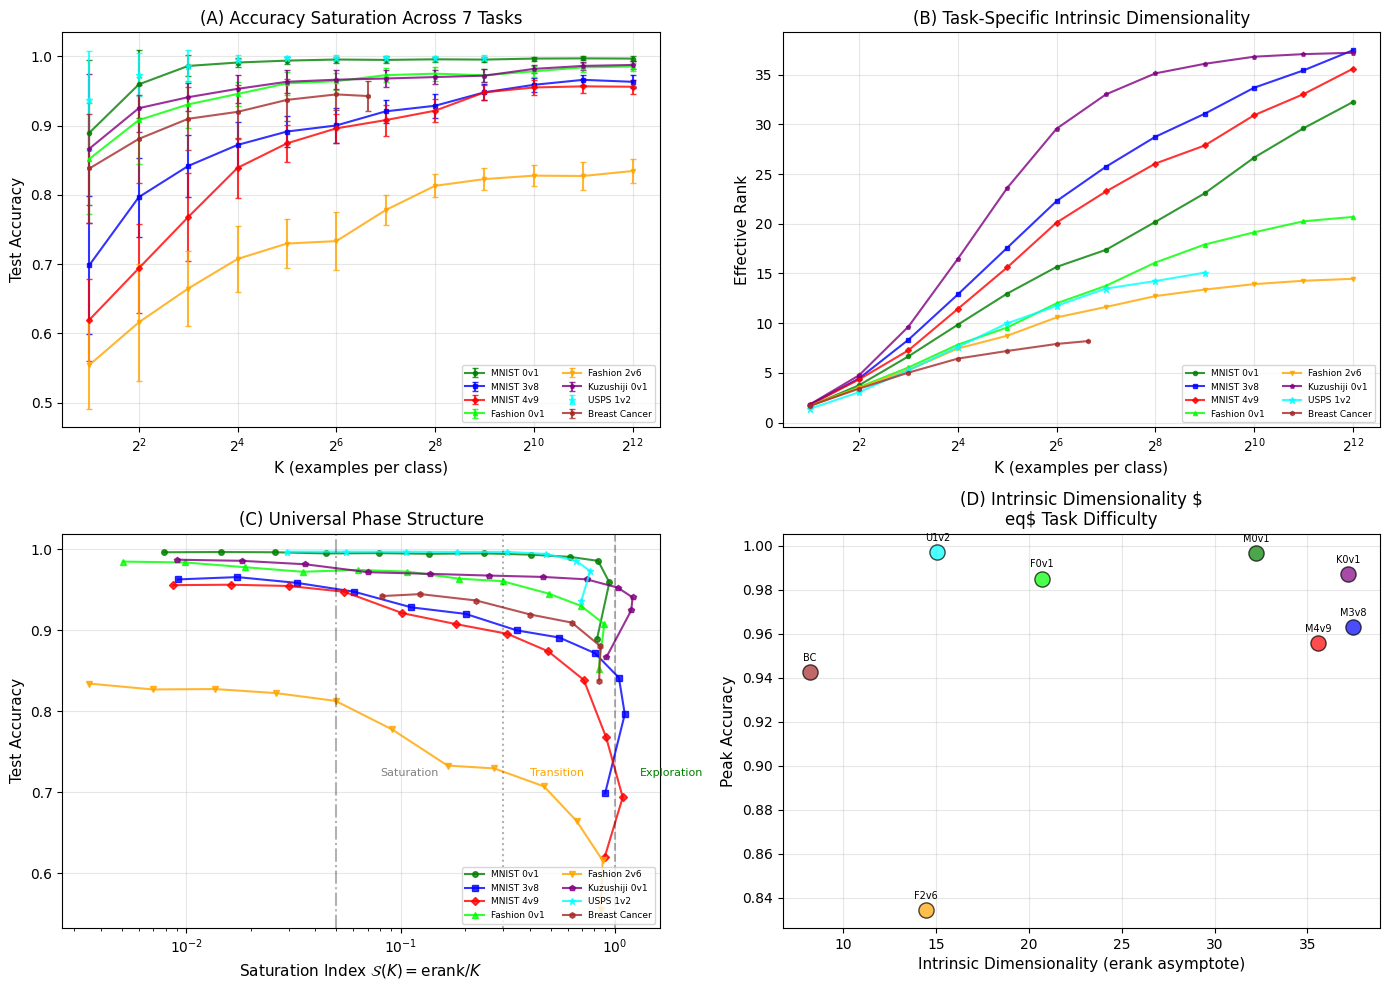

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Helper to extract from results dict
def extract(results):
    Ks = np.array([r['K'] for r in results])
    accs = np.array([r['mean_acc'] for r in results])
    stds = np.array([r['std_acc'] for r in results])
    eranks = np.array([r['mean_erank'] for r in results])
    Ss = eranks / Ks
    return Ks, accs, stds, eranks, Ss

# Extract all datasets
K_m01, acc_m01, std_m01, erank_m01, S_m01 = extract(all_results['MNIST_0v1'])
K_m38, acc_m38, std_m38, erank_m38, S_m38 = extract(all_results['MNIST_3v8'])
K_m49, acc_m49, std_m49, erank_m49, S_m49 = extract(all_results['MNIST_4v9'])
K_f01, acc_f01, std_f01, erank_f01, S_f01 = extract(all_results['Fashion_0v1'])
K_f26, acc_f26, std_f26, erank_f26, S_f26 = extract(all_results['Fashion_2v6'])
K_k01, acc_k01, std_k01, erank_k01, S_k01 = extract(all_results['Kuzushiji_0v1'])
K_u12, acc_u12, std_u12, erank_u12, S_u12 = extract(all_results['USPS_1v2'])
K_bc, acc_bc, std_bc, erank_bc, S_bc = extract(all_results['BreastCancer'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- PANEL A: Accuracy vs K ---
axes[0,0].errorbar(K_m01, acc_m01, yerr=std_m01, fmt='o-', color='green', label='MNIST 0v1', markersize=3, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_m38, acc_m38, yerr=std_m38, fmt='s-', color='blue', label='MNIST 3v8', markersize=3, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_m49, acc_m49, yerr=std_m49, fmt='D-', color='red', label='MNIST 4v9', markersize=3, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_f01, acc_f01, yerr=std_f01, fmt='^-', color='lime', label='Fashion 0v1', markersize=3, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_f26, acc_f26, yerr=std_f26, fmt='v-', color='orange', label='Fashion 2v6', markersize=3, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_k01, acc_k01, yerr=std_k01, fmt='p-', color='purple', label='Kuzushiji 0v1', markersize=3, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_u12, acc_u12, yerr=std_u12, fmt='*', color='cyan', label='USPS 1v2', markersize=5, capsize=2, alpha=0.8)
axes[0,0].errorbar(K_bc, acc_bc, yerr=std_bc, fmt='h-', color='brown', label='Breast Cancer', markersize=3, capsize=2, alpha=0.8)
axes[0,0].set_xlabel('K (examples per class)', fontsize=11)
axes[0,0].set_ylabel('Test Accuracy', fontsize=11)
axes[0,0].set_title('(A) Accuracy Saturation Across 7 Tasks', fontsize=12)
axes[0,0].set_xscale('log', base=2)
axes[0,0].legend(fontsize=6.5, ncol=2, loc='lower right')
axes[0,0].grid(True, alpha=0.3)

# --- PANEL B: Effective Rank Asymptotes ---
axes[0,1].plot(K_m01, erank_m01, 'o-', color='green', label='MNIST 0v1', markersize=3, alpha=0.8)
axes[0,1].plot(K_m38, erank_m38, 's-', color='blue', label='MNIST 3v8', markersize=3, alpha=0.8)
axes[0,1].plot(K_m49, erank_m49, 'D-', color='red', label='MNIST 4v9', markersize=3, alpha=0.8)
axes[0,1].plot(K_f01, erank_f01, '^-', color='lime', label='Fashion 0v1', markersize=3, alpha=0.8)
axes[0,1].plot(K_f26, erank_f26, 'v-', color='orange', label='Fashion 2v6', markersize=3, alpha=0.8)
axes[0,1].plot(K_k01, erank_k01, 'p-', color='purple', label='Kuzushiji 0v1', markersize=3, alpha=0.8)
axes[0,1].plot(K_u12, erank_u12, '*-', color='cyan', label='USPS 1v2', markersize=5, alpha=0.8)
axes[0,1].plot(K_bc, erank_bc, 'h-', color='brown', label='Breast Cancer', markersize=3, alpha=0.8)
axes[0,1].set_xlabel('K (examples per class)', fontsize=11)
axes[0,1].set_ylabel('Effective Rank', fontsize=11)
axes[0,1].set_title('(B) Task-Specific Intrinsic Dimensionality', fontsize=12)
axes[0,1].set_xscale('log', base=2)
axes[0,1].legend(fontsize=6.5, ncol=2, loc='lower right')
axes[0,1].grid(True, alpha=0.3)

# --- PANEL C: The Collapse on S(K) ---
axes[1,0].plot(S_m01, acc_m01, 'o-', color='green', label='MNIST 0v1', markersize=4, alpha=0.8)
axes[1,0].plot(S_m38, acc_m38, 's-', color='blue', label='MNIST 3v8', markersize=4, alpha=0.8)
axes[1,0].plot(S_m49, acc_m49, 'D-', color='red', label='MNIST 4v9', markersize=4, alpha=0.8)
axes[1,0].plot(S_f01, acc_f01, '^-', color='lime', label='Fashion 0v1', markersize=4, alpha=0.8)
axes[1,0].plot(S_f26, acc_f26, 'v-', color='orange', label='Fashion 2v6', markersize=4, alpha=0.8)
axes[1,0].plot(S_k01, acc_k01, 'p-', color='purple', label='Kuzushiji 0v1', markersize=4, alpha=0.8)
axes[1,0].plot(S_u12, acc_u12, '*-', color='cyan', label='USPS 1v2', markersize=5, alpha=0.8)
axes[1,0].plot(S_bc, acc_bc, 'h-', color='brown', label='Breast Cancer', markersize=4, alpha=0.8)
axes[1,0].axvline(x=1.0, color='black', linestyle='--', alpha=0.3)
axes[1,0].axvline(x=0.3, color='black', linestyle=':', alpha=0.3)
axes[1,0].axvline(x=0.05, color='black', linestyle='-.', alpha=0.3)
axes[1,0].text(1.3, 0.72, 'Exploration', fontsize=8, color='green')
axes[1,0].text(0.4, 0.72, 'Transition', fontsize=8, color='orange')
axes[1,0].text(0.08, 0.72, 'Saturation', fontsize=8, color='gray')
axes[1,0].set_xlabel(r'Saturation Index $\mathcal{S}(K) = \mathrm{erank}/K$', fontsize=11)
axes[1,0].set_ylabel('Test Accuracy', fontsize=11)
axes[1,0].set_title('(C) Universal Phase Structure', fontsize=12)
axes[1,0].set_xscale('log')
axes[1,0].legend(fontsize=6.5, ncol=2, loc='lower right')
axes[1,0].grid(True, alpha=0.3)

# --- PANEL D: The Decoupling ---
asymptotes = [32.24, 37.45, 35.58, 20.69, 14.46, 37.19, 15.08, 8.20]
peak_accs = [0.9966, 0.9630, 0.9559, 0.9851, 0.8344, 0.9873, 0.9973, 0.9425]
labels = ['M0v1', 'M3v8', 'M4v9', 'F0v1', 'F2v6', 'K0v1', 'U1v2', 'BC']
colors = ['green', 'blue', 'red', 'lime', 'orange', 'purple', 'cyan', 'brown']

for i, (x, y, lab, col) in enumerate(zip(asymptotes, peak_accs, labels, colors)):
    axes[1,1].scatter(x, y, s=120, c=col, alpha=0.7, edgecolors='black', zorder=5)
    axes[1,1].annotate(lab, (x, y), textcoords="offset points", 
                       xytext=(0, 8), ha='center', fontsize=7)

axes[1,1].set_xlabel('Intrinsic Dimensionality (erank asymptote)', fontsize=11)
axes[1,1].set_ylabel('Peak Accuracy', fontsize=11)
axes[1,1].set_title('(D) Intrinsic Dimensionality $\neq$ Task Difficulty', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_tmlr_master.png', dpi=200, bbox_inches='tight')
plt.show()